### Q3

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jdatetime

In [13]:
df_raw = pd.read_csv('../../data/Divar.csv')
display(df_raw.head())

C:\Users\M.Ali\AppData\Local\Temp\ipykernel_3728\3338449799.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../../data/Divar.csv')


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [34]:
df = df_raw.copy()
# حذف NaN ها از ستون cat2_slug
df = df.dropna(subset=['cat2_slug'])
# استخراج نوع معامله
conditions = [
    df['cat2_slug'].str.contains('rent', case=False, na=False),
    df['cat2_slug'].str.contains('sell', case=False, na=False)
]
choices = ['rent', 'sell']
df['deal_type'] = np.select(conditions, choices, default='other')

df = df[df['deal_type'] != 'other'].copy()

# تبدیل ستون زمان به فرمت استاندارد Datetime در پانداز
df['created_at_month'] = pd.to_datetime(df['created_at_month'])

# گروه‌بندی و شمارش آگهی‌ها
monthly_counts = df.groupby(['created_at_month', 'deal_type']).size().reset_index(name='ad_count')


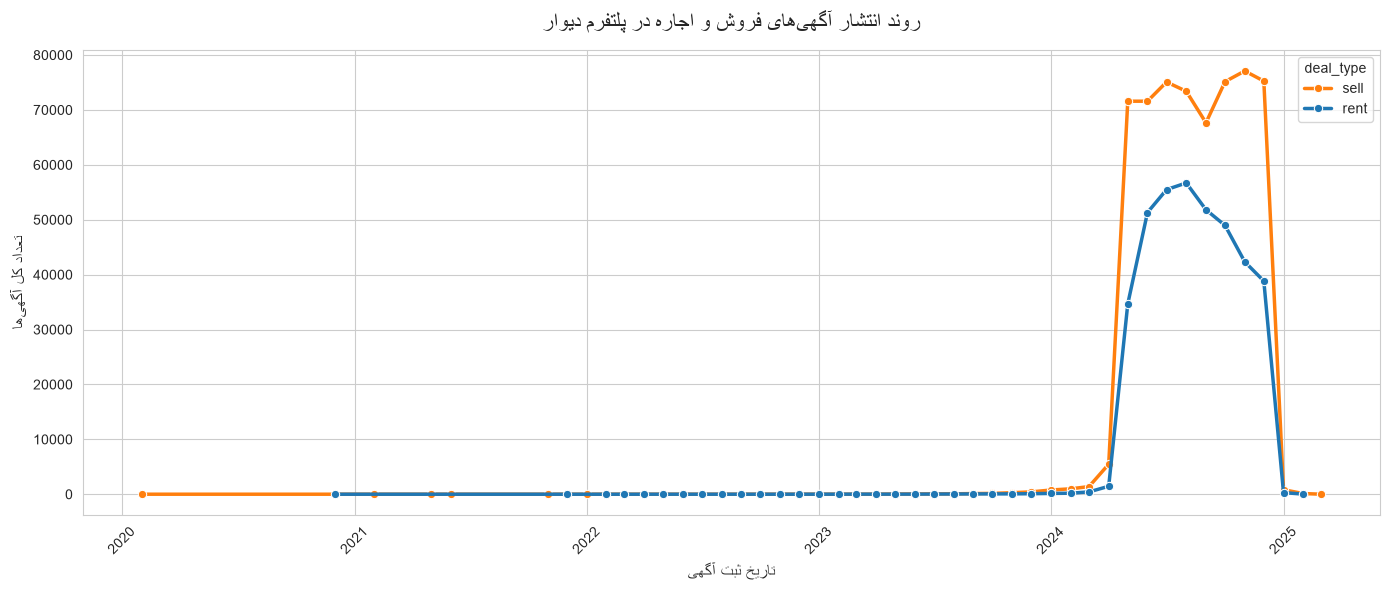

In [35]:
# رسم نمودار
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_counts, 
    x='created_at_month', 
    y='ad_count', 
    hue='deal_type', 
    marker='o', 
    linewidth=2.5,
    palette={'rent': '#1f77b4', 'sell': '#ff7f0e'}
)

plt.title('روند انتشار آگهی‌های فروش و اجاره در پلتفرم دیوار', fontsize=16, pad=15)
plt.xlabel('تاریخ ثبت آگهی', fontsize=12)
plt.ylabel('تعداد کل آگهی‌ها', fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()

plt.show()

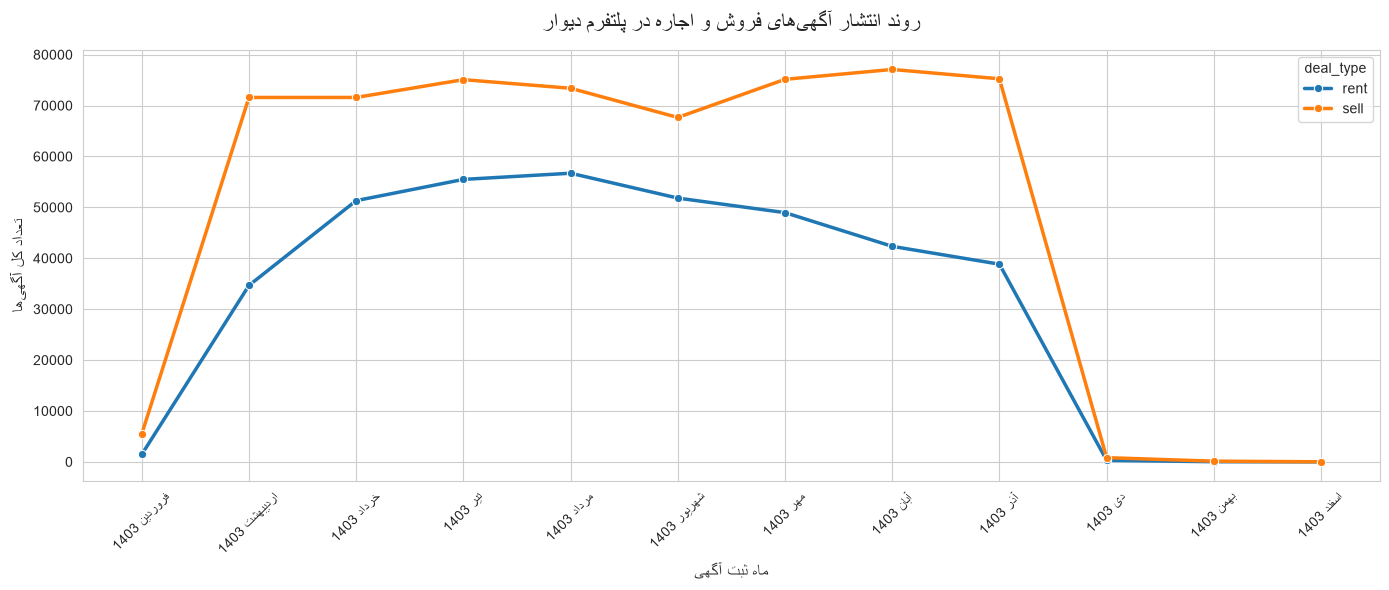

In [38]:
# فیلتر کردن دقیق برای کل سال ۱۴۰۳ (از فروردین تا اسفند)
df = df[(df['created_at_month'] >= '2024-03-20') & (df['created_at_month'] < '2025-03-21')].copy()
def convert_to_shamsi(greg_date):
    if pd.isnull(greg_date):
        return np.nan
    # تبدیل به تاریخ شمسی
    jalali_date = jdatetime.date.fromgregorian(date=greg_date.date())
    # استخراج نام ماه شمسی به همراه سال
    month_name = jdatetime.date.j_months_fa[jalali_date.month - 1]
    return f"{month_name} {jalali_date.year}"

# ساخت ستون جدید با تاریخ شمسی
df['shamsi_month'] = df['created_at_month'].apply(convert_to_shamsi)

# ترتیب زمانی درست را از روی همان تاریخ‌های میلادی استخراج و اعمال می‌کنیم
ordered_months = df.sort_values('created_at_month')['shamsi_month'].unique()
df['shamsi_month'] = pd.Categorical(df['shamsi_month'], categories=ordered_months, ordered=True)

# گروه‌بندی و رسم نمودار بر اساس ماه شمسی
monthly_counts = df.groupby(['shamsi_month', 'deal_type'], observed=False).size().reset_index(name='ad_count')

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_counts, 
    x='shamsi_month', 
    y='ad_count', 
    hue='deal_type', 
    marker='o', 
    linewidth=2.5
)

plt.title('روند انتشار آگهی‌های فروش و اجاره در پلتفرم دیوار', fontsize=16, pad=15)
plt.xlabel('ماه ثبت آگهی', fontsize=12)
plt.ylabel('تعداد کل آگهی‌ها', fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()

plt.show()

### Q8

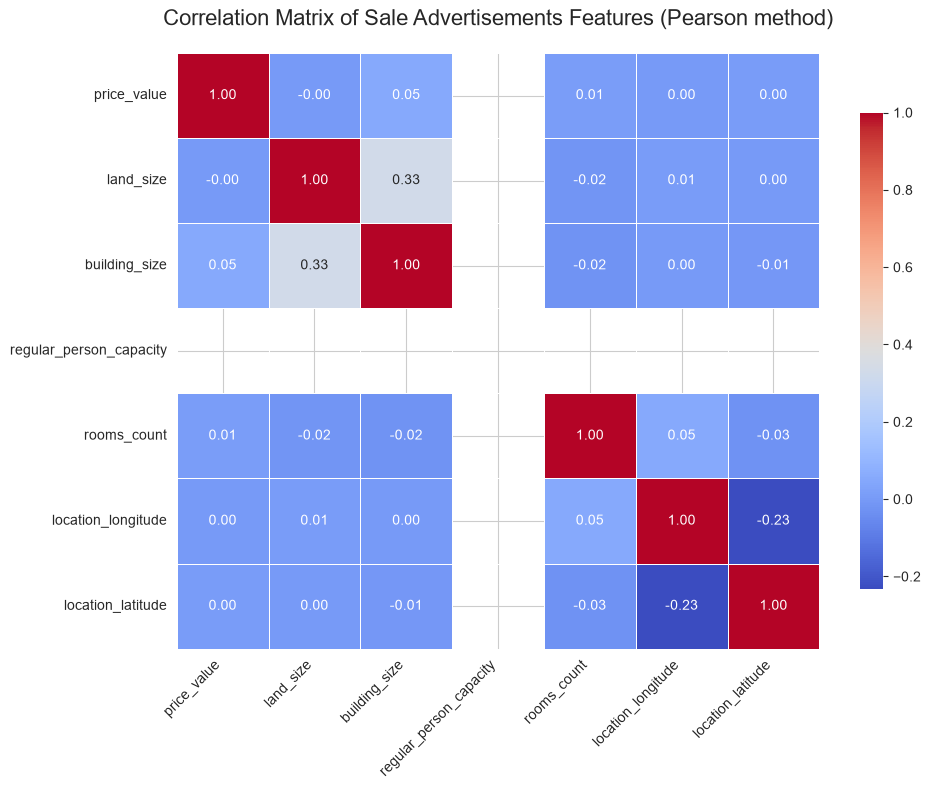

In [45]:
# فیلتر کردن آگهی‌های فروش (چون 'مبلغ قیمت' مختص این دسته است)
df_sale = df[df['deal_type'] == 'sell'].copy()

# دیکشنری مپینگ برای تبدیل تعداد اتاق از متن به عدد
room_mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج': 5,
    'پنج و بیشتر': 5
}

# جایگزینی کلمات با اعداد در ستون تعداد اتاق
df_sale['rooms_count'] = df_sale['rooms_count'].replace(room_mapping)

features = [
    'price_value', 
    'land_size', 
    'building_size', 
    'regular_person_capacity', 
    'rooms_count', 
    'location_longitude', 
    'location_latitude'
]

# تبدیل اجباری تمام ستون‌های فیچر به فرمت عددی
# پارامتر errors='coerce' کلمات پیش‌بینی‌نشده (مثل "توافقی") را به NaN تبدیل می‌کند تا ارور نگیریم
for col in features:
    df_sale[col] = pd.to_numeric(df_sale[col], errors='coerce')

# محاسبه و رسم ماتریس هم‌بستگی
corr_matrix = df_sale[features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix of Sale Advertisements Features (Pearson method)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

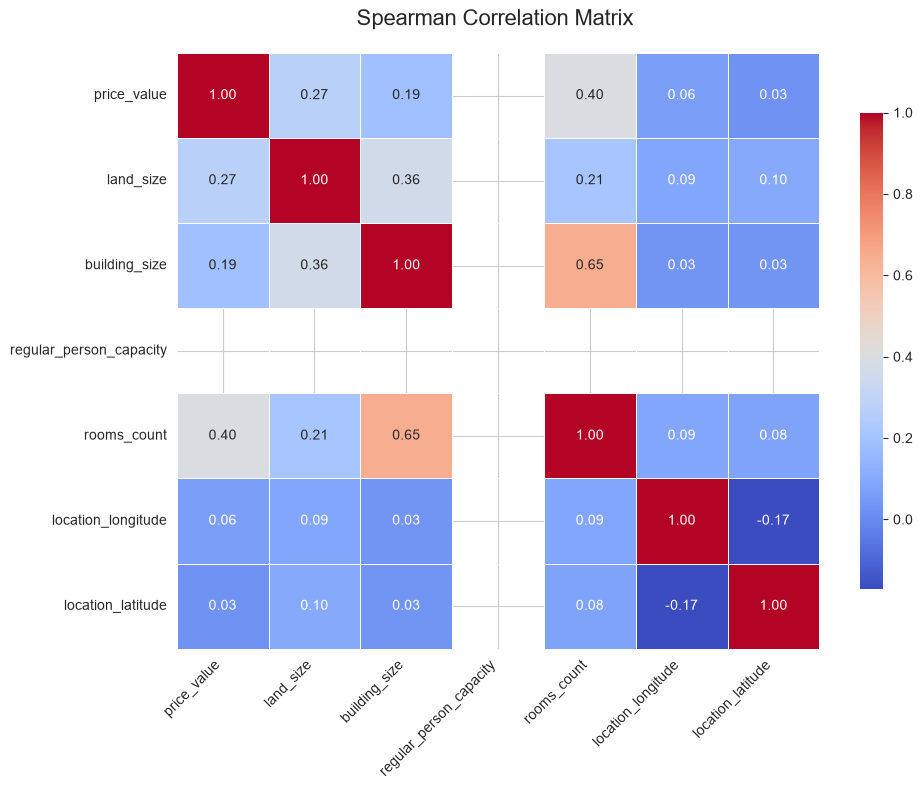

In [46]:
# محاسبه ماتریس هم‌بستگی با روش اسپیرمن روی داده‌های "خام و دارای نویز"
corr_matrix_spearman = df_sale[features].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_spearman, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    cbar_kws={'shrink': 0.8}
)

plt.title('Spearman Correlation Matrix ', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

تعداد آگهی‌ها قبل از پاک‌سازی: 593179
تعداد آگهی‌ها بعد از پاک‌سازی: 457051


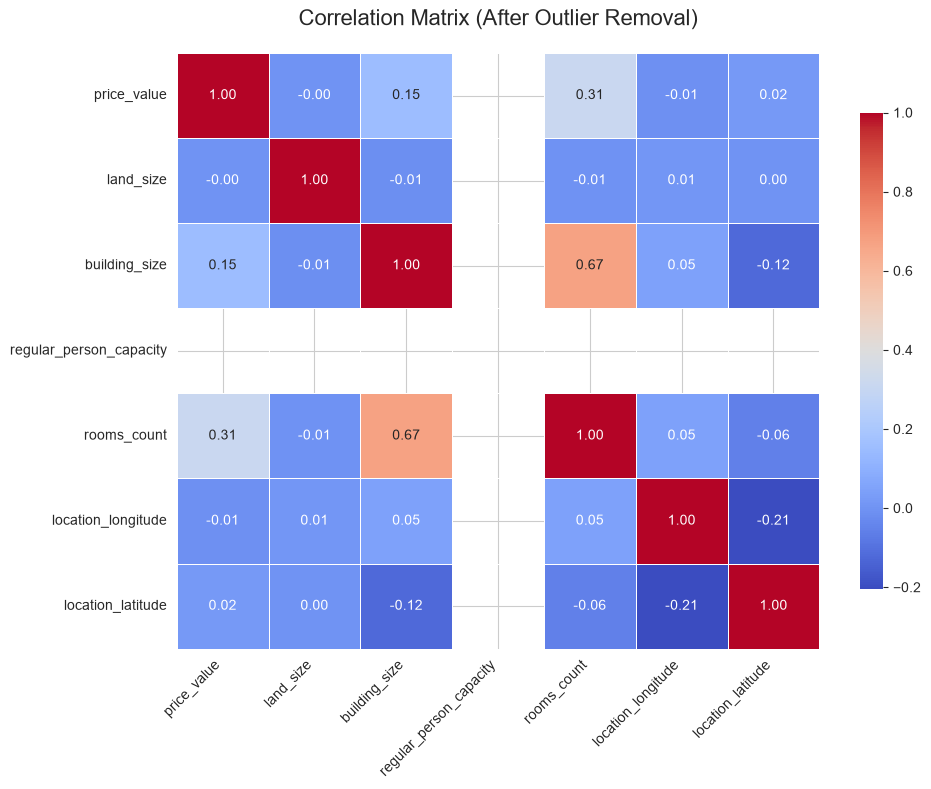

In [47]:
# فیلتر کردن داده‌های پرت (Outliers) با روش آماری IQR
df_sale_filtered = df_sale.copy()
# تعریف یک تابع برای محاسبه مرزها و فیلتر کردن
def remove_outliers_iqr(df, column):
    # محاسبه چارک اول (25%) و چارک سوم (75%)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # تعریف مرز پایین و بالا
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # نگه داشتن داده‌هایی که داخل این مرز منطقی هستند
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# اعمال تابع روی مبلغ قیمت و زیربنا
df_sale_filtered = remove_outliers_iqr(df_sale_filtered, 'price_value')
df_sale_filtered = remove_outliers_iqr(df_sale_filtered, 'building_size')

print(f"تعداد آگهی‌ها قبل از پاک‌سازی: {len(df_sale)}")
print(f"تعداد آگهی‌ها بعد از پاک‌سازی: {len(df_sale_filtered)}")

# محاسبه و رسم ماتریس هم‌بستگی جدید
corr_matrix_filtered = df_sale_filtered[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_filtered, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix (After Outlier Removal)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()